# Thermosolutal convection of a Navier-Stokes fluid in a rectangle

$$
\mathbb{S}
\begin{cases}
\Omega = [0, \mathcal{A}X] \times [0, X] & \text{aspect ratio } \mathcal{A}=\mathcal{O}(1)\\
\textbf{e}_g=-\textbf{e}_y & \text{vertically downward gravity} \\
\rho(c, \theta) = c - \beta\theta & \text{constitutive relation} \\
c_0(x,y)=y+\mathcal{N}(x,y) & \text{perturbed diffusive base state} \\
\theta_0(x,y)=1-y+\mathcal{N}(x,y) \\ 
\textbf{u}_0 = \textbf{0} \\
p_0 = 0 \\
c_{\text{D}}(x,y=0)=0 & \text{prescribed concentration on upper and lower boundaries} \\
c_{\text{D}}(x,y=1)=1 \\
\theta_{\text{D}}(x,y=0)=1 & \text{prescribed temperature on upper and lower boundaries} \\
\theta_{\text{D}}(x,y=1)=0 \\
c_{\text{N}}(x=0,y)=0 & \text{no-flux on left and right boundaries}\\
c_{\text{N}}(x=L_x,y)=0 \\
\theta_{\text{N}}(x=0,y)=0 & \\
\theta_{\text{N}}(x=L_x,y)=0 \\
\textbf{u}_{\text{E}}\vert_{\partial\Omega}=\textbf{0} & \text{no-flow on entire boundary}
\end{cases}
$$

In [ ]:
from lucifex.sim import run
from lucifex.utils.array_utils import as_indices
from lucifex.viz import (
    plot_line, create_animation, plot_colormap,
    save_figure, display_animation, plot_colormap_multifigure,
)
from lucifex.solver import maximum
from py.C31_navier_stokes_thermosolutal import navier_stokes_thermosolutal_rectangle

simulation = navier_stokes_thermosolutal_rectangle(
    aspect=2.0,
    Nx=64,
    Ny=64,
    Ra=5e4,
    beta=2.0,
    Le=10.0,
    dt_max=0.01, 
)

n_stop = 400
dt_init = 1e-6 
n_init = 10
run(simulation, n_stop=n_stop, dt_init=dt_init, n_init=n_init)

c, theta, rho, u = simulation['c', 'theta', 'rho', 'u']
mesh = c.mesh

In [2]:
title_triplet = lambda time_triplet, tex_triplet: (
    tuple(f'${n}(t={t:.6f})$' for t, n in zip(time_triplet, tex_triplet))
)
series_triplet = (c, theta, rho)
tex_triplet = ('c', '\\theta', '\\rho')

In [3]:
time_slice = slice(0, None, 2)
time_triplet_series = [ti for ti in zip(*[s.time_series[time_slice] for s in series_triplet])]

anim = create_animation(
    plot_colormap_multifigure(n_cols=3, colorbar=False),
    cmaps=('hot', 'magma', 'plasma'),
)(
    [ui for ui in zip(*[s.series[time_slice] for s in series_triplet])],
    titles=[title_triplet(i, tex_triplet) for i in time_triplet_series],
)
anim_path = save_figure('c(x,y,t)_theta(x,y,t)_rho(x,y,t)', get_path=True)(anim)

display_animation(anim_path)

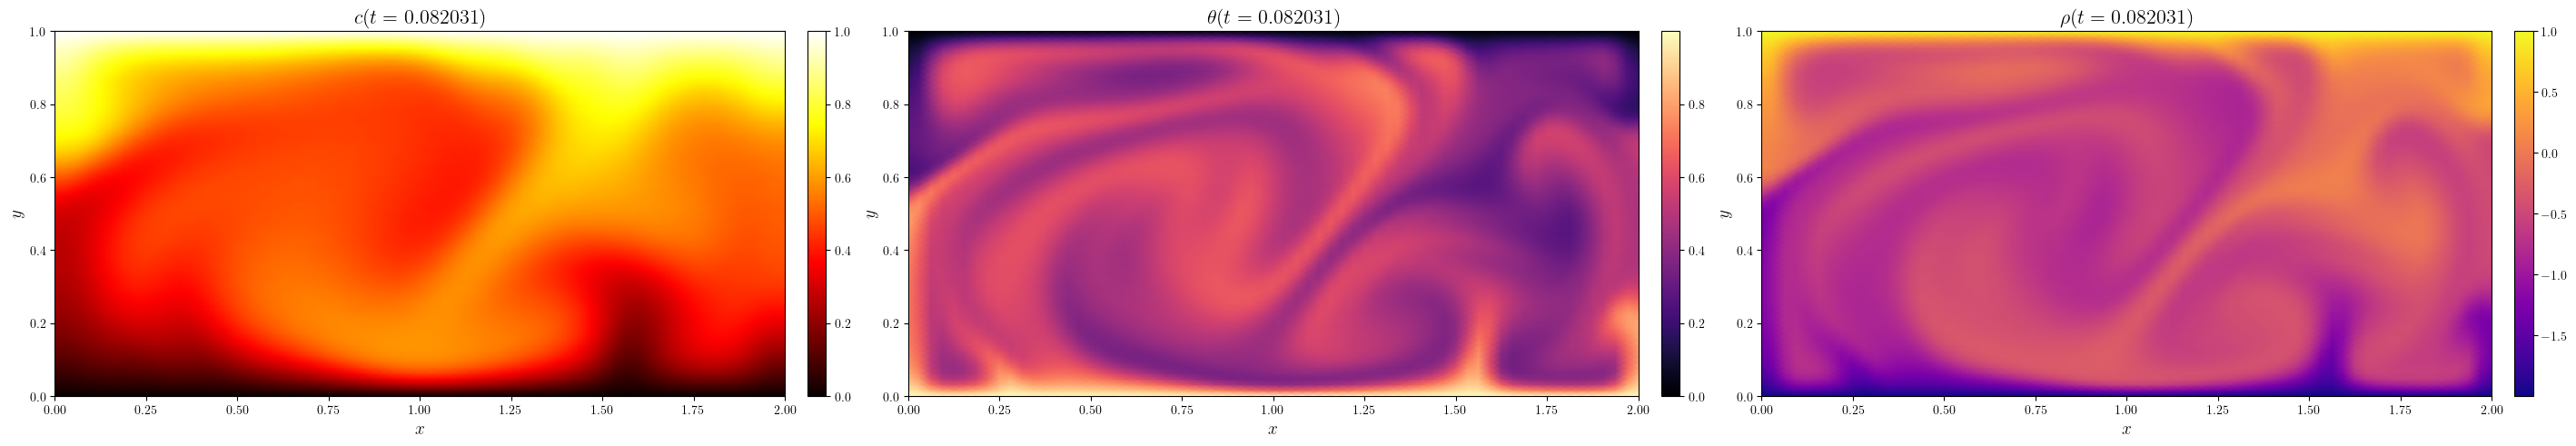

In [4]:
time_index = -1
time_triplet = tuple(u.time_series[time_index] for u in series_triplet)

fig, *axes = plot_colormap_multifigure(n_cols=3, colorbar=True)(
    [u.series[time_index] for u in series_triplet],
    ('hot', 'magma', 'plasma'),
    titles=title_triplet(time_triplet, tex_triplet),
)
save_figure(f'c(x,y,t={time_triplet[0]})_theta(x,y,t={time_triplet[1]})_rho(x,y,t={time_triplet[2]})')(fig)

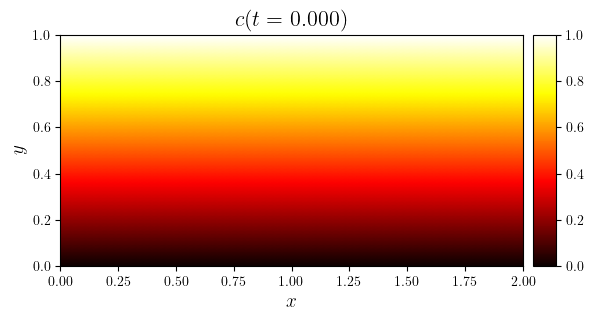

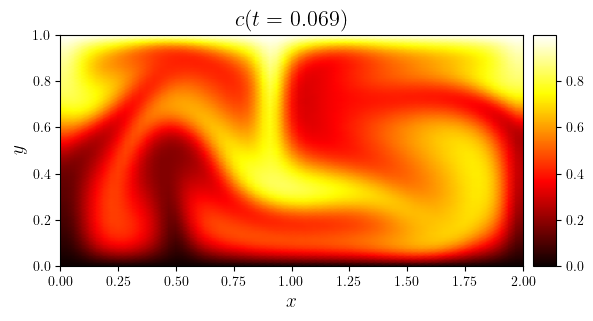

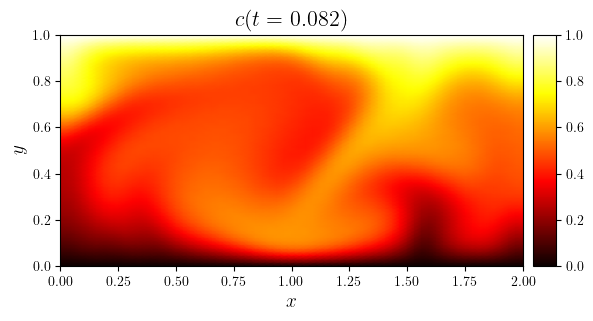

In [ ]:
time_indices = as_indices(rho.time_series, (0, 0.5, -1), fraction=True)
for i in time_indices:
    fig, ax = plot_colormap(rho.series[i], 'plasma', title=f'$c(t={rho.time_series[i]:.3f})$')
    save_figure(f'c(x,y,t={rho.time_series[i]:.3f})', thumbnail=(i == -1))(fig)

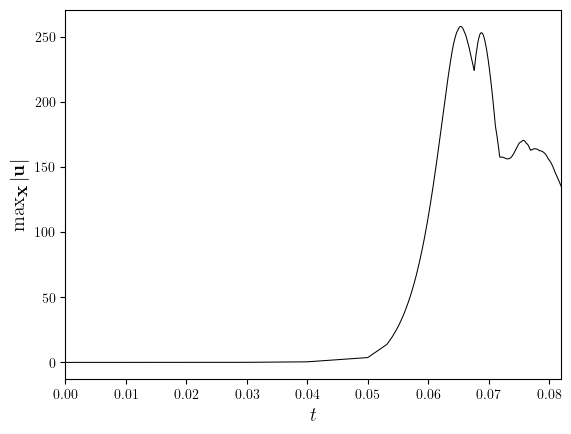

In [6]:
uMax = [maximum(i) for i in u.series]
fig, ax = plot_line(
    (u.time_series, uMax), 
    x_label='$t$', 
    y_label='$\max_{\\textbf{x}}|\\textbf{u}|$',
)
save_figure('uMax(t)')(fig)